# K-Medoids with Gower Distance: Haversine + Categorical Features

This notebook tackles a common real-world problem: clustering data that has **both** geographic coordinates **and** categorical attributes.

## The Challenge

Imagine you have a dataset of 300 weather stations, each with:
- **(lat, lon)** — position on the globe
- **climate** — tropical, arid, temperate, continental, polar
- **terrain** — coastal, mountain, plains, forest

Two stations might be geographically close but in very different climates (e.g., a mountain station and a coastal station 50 km apart). Or they might be on opposite sides of the world but share the same climate and terrain.

How do you measure "similarity" across such different feature types?

## Gower Distance: The Panel of Judges

**Analogy:** Think of Gower distance as a panel of judges scoring a talent show:
- **Judge 1 (Geography):** Scores how far apart two stations are on the globe, normalized to [0, 1]. Uses Haversine distance.
- **Judge 2 (Climate):** Gives 0 if climates match, 1 if they differ.
- **Judge 3 (Terrain):** Gives 0 if terrains match, 1 if they differ.

The **Gower distance** is simply the weighted average of all judges' scores:

$$d_{\text{Gower}}(a, b) = \frac{w_{\text{geo}} \cdot d_{\text{geo}}(a,b) + w_{\text{climate}} \cdot d_{\text{climate}}(a,b) + w_{\text{terrain}} \cdot d_{\text{terrain}}(a,b)}{w_{\text{geo}} + w_{\text{climate}} + w_{\text{terrain}}}$$

Result is always in [0, 1]. Clean, interpretable, and works with any combination of feature types.

## 1. Setup & Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

np.random.seed(42)
R = 1.0  # unit sphere

# Category definitions
CLIMATES = ['tropical', 'arid', 'temperate', 'continental', 'polar']
TERRAINS = ['coastal', 'mountain', 'plains', 'forest']

print("Setup complete!")
print(f"Climate categories: {CLIMATES}")
print(f"Terrain categories: {TERRAINS}")

Setup complete!
Climate categories: ['tropical', 'arid', 'temperate', 'continental', 'polar']
Terrain categories: ['coastal', 'mountain', 'plains', 'forest']


## 2. Generate Mixed Data: Geography + Categories

We create 5 clusters that are interesting because they **don't perfectly align** across features:
- Some clusters are geographically close but categorically different
- Some are geographically far but categorically similar

This is where a blended distance really earns its keep.

In [2]:
def haversine(lat1, lon1, lat2, lon2, r=1.0):
    """Great-circle distance on a sphere."""
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0)**2
    a = np.clip(a, 0, 1)
    return 2 * r * np.arcsin(np.sqrt(a))


def latlon_to_cartesian(lat, lon, r=1.0):
    x = r * np.cos(lat) * np.cos(lon)
    y = r * np.cos(lat) * np.sin(lon)
    z = r * np.sin(lat)
    return x, y, z


def generate_mixed_data(n_points=300, n_clusters=5, seed=42):
    """
    Generate points on a sphere with categorical features.
    
    Each cluster has:
    - A geographic center (lat, lon)
    - A dominant climate (with some noise)
    - A dominant terrain (with some noise)
    
    Some clusters are deliberately placed geographically close but with
    different categories to make the problem interesting.
    """
    rng = np.random.default_rng(seed)
    spread_rad = np.deg2rad(12)
    
    # (center_lat_deg, center_lon_deg, dominant_climate, dominant_terrain, climate_purity, terrain_purity)
    # purity: probability of getting the dominant category (rest is random)
    cluster_defs = [
        # Cluster 1 & 2: geographically CLOSE but categorically DIFFERENT
        (20, 40,    'tropical',     'coastal',   0.85, 0.80),   # tropical coast
        (25, 50,    'arid',         'plains',    0.85, 0.80),   # nearby but arid plains
        # Cluster 3: far away, unique
        (-50, -70,  'polar',        'mountain',  0.90, 0.85),   # southern mountain polar
        # Cluster 4 & 5: geographically FAR but categorically SIMILAR
        (55, 10,    'temperate',    'forest',    0.85, 0.80),   # Europe-ish temperate forest
        (50, 140,   'temperate',    'forest',    0.85, 0.80),   # East Asia temperate forest
    ]
    
    points_per = n_points // n_clusters
    all_lats, all_lons = [], []
    all_climates, all_terrains = [], []
    all_labels = []
    
    for i, (clat, clon, dom_climate, dom_terrain, c_pur, t_pur) in enumerate(cluster_defs[:n_clusters]):
        n = points_per if i < n_clusters - 1 else n_points - points_per * (n_clusters - 1)
        
        # Geographic coordinates
        clat_r, clon_r = np.deg2rad(clat), np.deg2rad(clon)
        dlat = rng.normal(0, spread_rad, size=n)
        dlon = rng.normal(0, spread_rad / max(np.cos(clat_r), 0.1), size=n)
        pt_lats = np.clip(clat_r + dlat, -np.pi/2, np.pi/2)
        pt_lons = (clon_r + dlon + np.pi) % (2 * np.pi) - np.pi
        
        # Categorical features with controlled purity
        climates = []
        terrains = []
        for _ in range(n):
            if rng.random() < c_pur:
                climates.append(dom_climate)
            else:
                climates.append(rng.choice(CLIMATES))
            if rng.random() < t_pur:
                terrains.append(dom_terrain)
            else:
                terrains.append(rng.choice(TERRAINS))
        
        all_lats.append(pt_lats)
        all_lons.append(pt_lons)
        all_climates.extend(climates)
        all_terrains.extend(terrains)
        all_labels.append(np.full(n, i))
    
    return {
        'lats': np.concatenate(all_lats),
        'lons': np.concatenate(all_lons),
        'climate': np.array(all_climates),
        'terrain': np.array(all_terrains),
        'true_labels': np.concatenate(all_labels),
        'cluster_defs': cluster_defs[:n_clusters],
    }


K = 5
data = generate_mixed_data(n_points=300, n_clusters=K)

print(f"Generated {len(data['lats'])} points with {K} clusters\n")
print("Cluster design:")
print(f"  1 & 2: Geographically CLOSE, categorically DIFFERENT (tropical-coast vs arid-plains)")
print(f"  3:     Unique (polar mountain, southern hemisphere)")
print(f"  4 & 5: Geographically FAR, categorically SIMILAR (both temperate-forest)")
print(f"\nClimate distribution: {dict(zip(*np.unique(data['climate'], return_counts=True)))}")
print(f"Terrain distribution: {dict(zip(*np.unique(data['terrain'], return_counts=True)))}")

Generated 300 points with 5 clusters

Cluster design:
  1 & 2: Geographically CLOSE, categorically DIFFERENT (tropical-coast vs arid-plains)
  3:     Unique (polar mountain, southern hemisphere)
  4 & 5: Geographically FAR, categorically SIMILAR (both temperate-forest)

Climate distribution: {np.str_('arid'): np.int64(59), np.str_('continental'): np.int64(5), np.str_('polar'): np.int64(63), np.str_('temperate'): np.int64(110), np.str_('tropical'): np.int64(63)}
Terrain distribution: {np.str_('coastal'): np.int64(62), np.str_('forest'): np.int64(109), np.str_('mountain'): np.int64(66), np.str_('plains'): np.int64(63)}


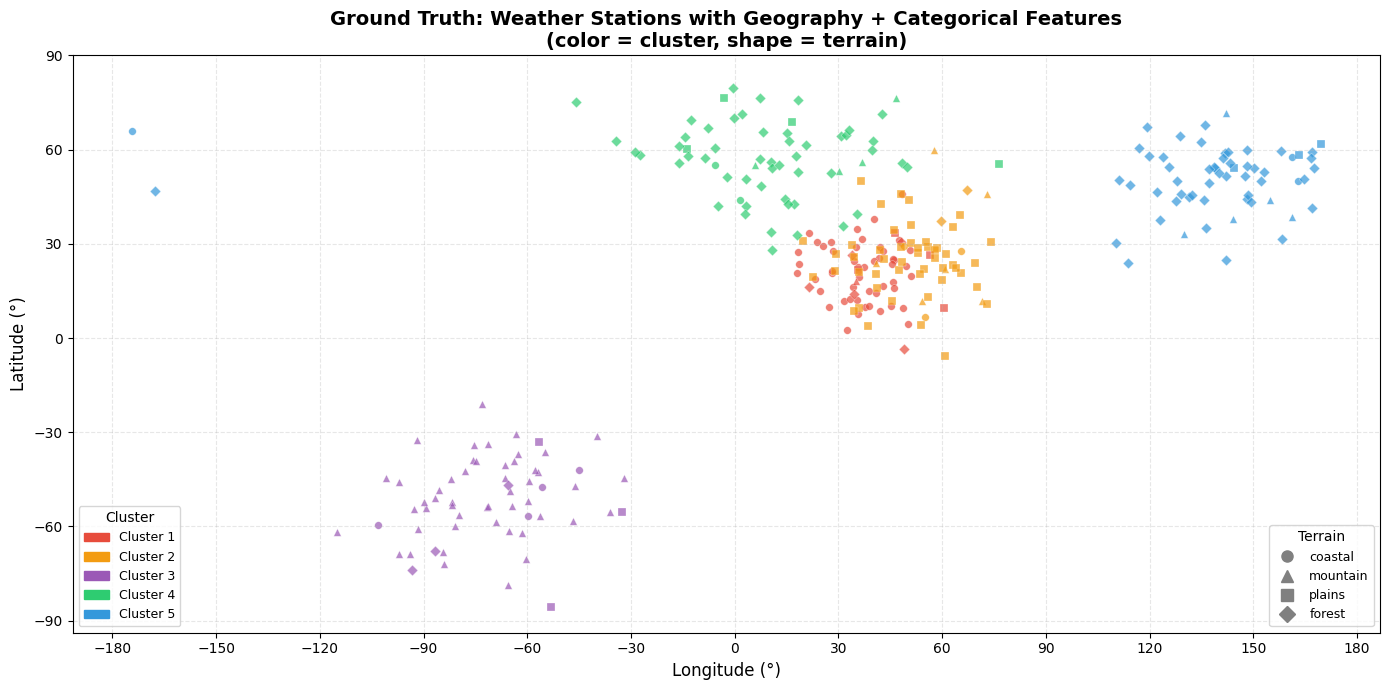

💡 Notice: Clusters 1 & 2 (red & orange) are geographically close but different categories
   Clusters 4 & 5 (green & blue) are far apart but same categories


In [3]:
# Quick peek: map with ground truth clusters
cluster_colors = ['#e74c3c', '#f39c12', '#9b59b6', '#2ecc71', '#3498db']
terrain_markers = {'coastal': 'o', 'mountain': '^', 'plains': 's', 'forest': 'D'}

fig, ax = plt.subplots(figsize=(14, 7))

for i in range(K):
    mask = data['true_labels'] == i
    for terrain, marker in terrain_markers.items():
        t_mask = mask & (data['terrain'] == terrain)
        if np.sum(t_mask) > 0:
            ax.scatter(np.rad2deg(data['lons'][t_mask]), np.rad2deg(data['lats'][t_mask]),
                       c=cluster_colors[i], marker=marker, s=30, alpha=0.7,
                       edgecolors='white', linewidths=0.3)

# Legend for terrain shapes
terrain_handles = [Line2D([0], [0], marker=m, color='gray', markerfacecolor='gray',
                          markersize=8, linestyle='None', label=t)
                   for t, m in terrain_markers.items()]
# Legend for clusters
cluster_handles = [mpatches.Patch(color=cluster_colors[i], label=f'Cluster {i+1}')
                   for i in range(K)]

leg1 = ax.legend(handles=cluster_handles, loc='lower left', fontsize=9, title='Cluster')
ax.add_artist(leg1)
ax.legend(handles=terrain_handles, loc='lower right', fontsize=9, title='Terrain')

ax.set_xticks(np.arange(-180, 181, 30))
ax.set_yticks(np.arange(-90, 91, 30))
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_xlabel('Longitude (°)', fontsize=12)
ax.set_ylabel('Latitude (°)', fontsize=12)
ax.set_title('Ground Truth: Weather Stations with Geography + Categorical Features\n'
             '(color = cluster, shape = terrain)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("💡 Notice: Clusters 1 & 2 (red & orange) are geographically close but different categories")
print("   Clusters 4 & 5 (green & blue) are far apart but same categories")

## 3. Gower Distance Implementation

Our custom Gower distance combines:
- **Haversine distance** (normalized to [0, 1] by dividing by max possible distance π)
- **Simple matching** for each categorical feature (0 = same, 1 = different)

All components are weighted and averaged.

In [4]:
def gower_distance_matrix(data, w_geo=1.0, w_climate=1.0, w_terrain=1.0):
    """
    Compute N×N Gower distance matrix for mixed geographic + categorical data.
    
    Components:
    - Geographic: Haversine distance normalized to [0, 1]
    - Climate:    Simple matching (0 if same, 1 if different)
    - Terrain:    Simple matching (0 if same, 1 if different)
    
    Weights control the relative importance of each component.
    """
    n = len(data['lats'])
    lats = data['lats']
    lons = data['lons']
    climate = data['climate']
    terrain = data['terrain']
    
    # Maximum possible Haversine distance on unit sphere = π
    max_hav = np.pi * R
    
    total_weight = w_geo + w_climate + w_terrain
    
    D = np.zeros((n, n))
    for i in range(n):
        # Geographic component (vectorized over j)
        d_geo = haversine(lats[i], lons[i], lats, lons, R) / max_hav  # [0, 1]
        
        # Categorical components
        d_climate = (climate[i] != climate).astype(float)  # 0 or 1
        d_terrain = (terrain[i] != terrain).astype(float)  # 0 or 1
        
        # Weighted average
        D[i, :] = (w_geo * d_geo + w_climate * d_climate + w_terrain * d_terrain) / total_weight
    
    return D


# Also build component-only matrices for the ablation study later
def geo_only_distance_matrix(data):
    """Haversine-only distance, normalized to [0, 1]."""
    return gower_distance_matrix(data, w_geo=1.0, w_climate=0.0, w_terrain=0.0)


def cat_only_distance_matrix(data):
    """Categorical-only distance (average of climate + terrain matching)."""
    return gower_distance_matrix(data, w_geo=0.0, w_climate=1.0, w_terrain=1.0)


# Compute the full blended Gower matrix
D_gower = gower_distance_matrix(data, w_geo=1.0, w_climate=1.0, w_terrain=1.0)
D_geo = geo_only_distance_matrix(data)
D_cat = cat_only_distance_matrix(data)

print(f"Distance matrix shape: {D_gower.shape}")
print(f"\nGower (blended):    range [{D_gower[D_gower>0].min():.4f}, {D_gower.max():.4f}], mean = {D_gower.mean():.4f}")
print(f"Geographic only:    range [{D_geo[D_geo>0].min():.4f}, {D_geo.max():.4f}], mean = {D_geo.mean():.4f}")
print(f"Categorical only:   range [{D_cat[D_cat>0].min():.4f}, {D_cat.max():.4f}], mean = {D_cat.mean():.4f}")

# Sanity: pick two points from same cluster — should be small
i1 = np.where(data['true_labels'] == 0)[0][0]
i2 = np.where(data['true_labels'] == 0)[0][1]
print(f"\nSanity check (two points from Cluster 1):")
print(f"  Gower = {D_gower[i1, i2]:.4f},  Geo = {D_geo[i1, i2]:.4f},  Cat = {D_cat[i1, i2]:.4f}")

# Two points from different clusters (1 vs 3, geographically and categorically far)
i3 = np.where(data['true_labels'] == 2)[0][0]
print(f"  vs point from Cluster 3:")
print(f"  Gower = {D_gower[i1, i3]:.4f},  Geo = {D_geo[i1, i3]:.4f},  Cat = {D_cat[i1, i3]:.4f}")

Distance matrix shape: (300, 300)

Gower (blended):    range [0.0005, 0.9993], mean = 0.6240
Geographic only:    range [0.0014, 0.9980], mean = 0.4008
Categorical only:   range [0.5000, 1.0000], mean = 0.7356

Sanity check (two points from Cluster 1):
  Gower = 0.0427,  Geo = 0.1282,  Cat = 0.0000
  vs point from Cluster 3:
  Gower = 0.8441,  Geo = 0.5322,  Cat = 1.0000


## 4. K-Medoids (PAM) Algorithm

In [5]:
def kmedoids_pam(D, k=5, max_iter=100, seed=123):
    """
    K-Medoids clustering using PAM (BUILD + SWAP).
    Takes any precomputed N×N distance matrix.
    """
    rng = np.random.default_rng(seed)
    n = D.shape[0]
    
    # BUILD: greedy medoid initialization
    medoids = [int(np.argmin(D.sum(axis=1)))]
    
    for _ in range(1, k):
        dist_to_nearest = D[:, medoids].min(axis=1)
        candidates = [i for i in range(n) if i not in medoids]
        best_gain, best_c = -np.inf, candidates[0]
        for c in candidates:
            gain = np.sum(np.maximum(dist_to_nearest - D[:, c], 0))
            if gain > best_gain:
                best_gain, best_c = gain, c
        medoids.append(best_c)
    
    medoids = np.array(medoids)
    dist_to_med = D[:, medoids]
    labels = np.argmin(dist_to_med, axis=1)
    total_cost = sum(dist_to_med[i, labels[i]] for i in range(n))
    history = [total_cost]
    
    # SWAP: iteratively improve
    for iteration in range(max_iter):
        best_swap, best_delta = None, 0
        non_medoids = [i for i in range(n) if i not in medoids]
        
        for m_idx in range(k):
            for h in non_medoids:
                new_med = medoids.copy()
                new_med[m_idx] = h
                new_d = D[:, new_med]
                new_l = np.argmin(new_d, axis=1)
                new_cost = sum(new_d[i, new_l[i]] for i in range(n))
                delta = new_cost - total_cost
                if delta < best_delta:
                    best_delta, best_swap = delta, (m_idx, h)
        
        if best_swap is None:
            print(f"  Converged at swap iteration {iteration + 1}")
            break
        
        medoids[best_swap[0]] = best_swap[1]
        dist_to_med = D[:, medoids]
        labels = np.argmin(dist_to_med, axis=1)
        total_cost = sum(dist_to_med[i, labels[i]] for i in range(n))
        history.append(total_cost)
    
    return labels, medoids, history


# Run K-Medoids with blended Gower distance
print("Running K-Medoids with Gower distance (geo + categorical)...")
gower_labels, gower_medoids, gower_history = kmedoids_pam(D_gower, k=K)
print(f"  Cluster sizes: {[np.sum(gower_labels == i) for i in range(K)]}")

# Also run with geography-only and categorical-only for comparison
print("\nRunning K-Medoids with geography-only distance...")
geo_labels, geo_medoids, geo_history = kmedoids_pam(D_geo, k=K)
print(f"  Cluster sizes: {[np.sum(geo_labels == i) for i in range(K)]}")

print("\nRunning K-Medoids with categorical-only distance...")
cat_labels, cat_medoids, cat_history = kmedoids_pam(D_cat, k=K)
print(f"  Cluster sizes: {[np.sum(cat_labels == i) for i in range(K)]}")

Running K-Medoids with Gower distance (geo + categorical)...
  Converged at swap iteration 5
  Cluster sizes: [np.int64(57), np.int64(61), np.int64(64), np.int64(59), np.int64(59)]

Running K-Medoids with geography-only distance...
  Converged at swap iteration 4
  Cluster sizes: [np.int64(70), np.int64(60), np.int64(60), np.int64(57), np.int64(53)]

Running K-Medoids with categorical-only distance...
  Converged at swap iteration 2
  Cluster sizes: [np.int64(121), np.int64(20), np.int64(54), np.int64(61), np.int64(44)]


## 5. Visualization

### 5a. Gower Clustering — Map with Categorical Markers

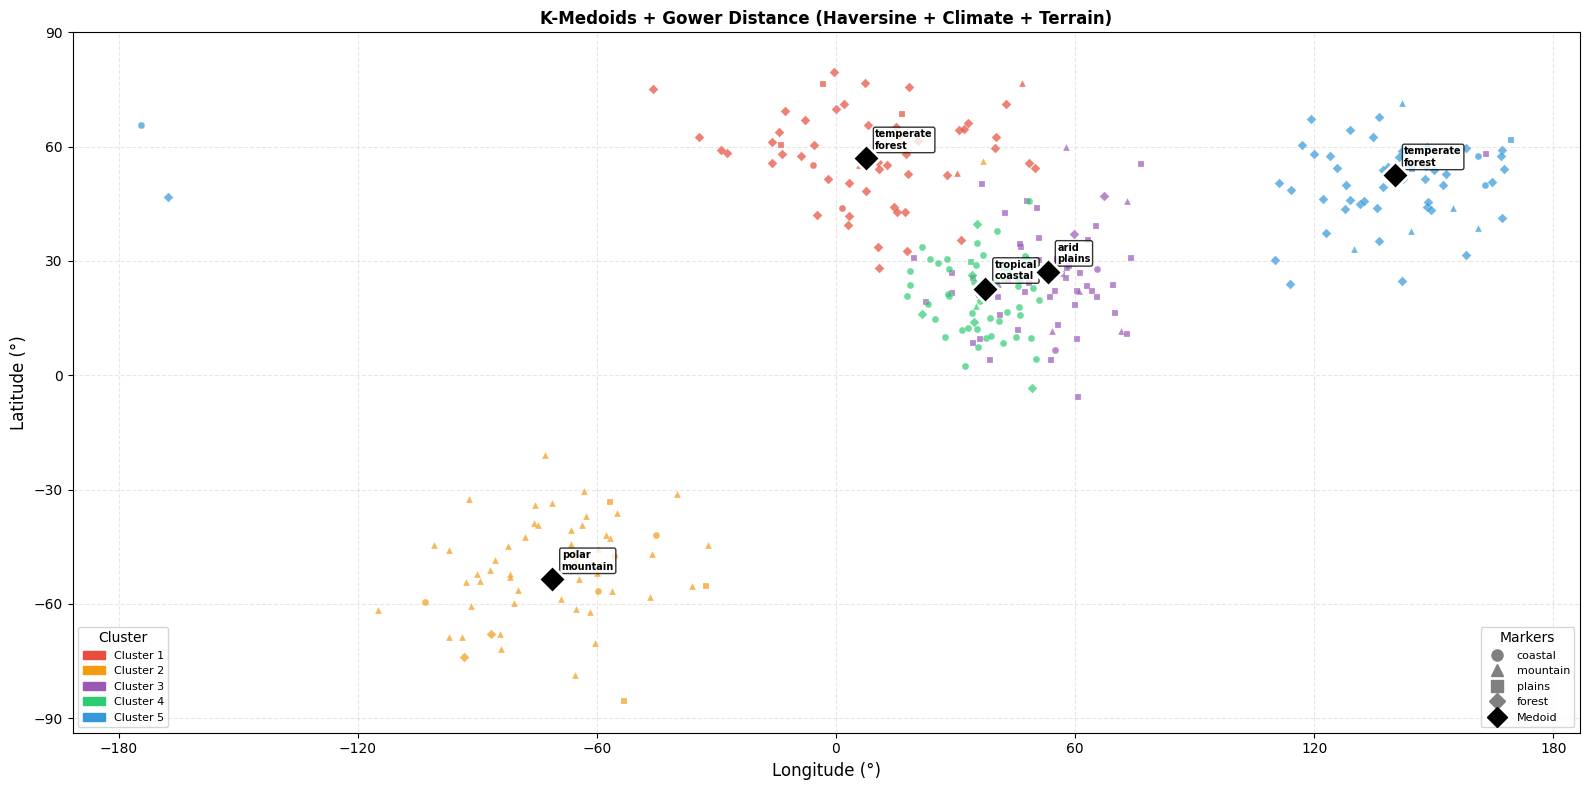


Medoid profiles (the representative point for each cluster):
  Cluster 1: (56.9°, 7.4°) | climate=temperate, terrain=forest
  Cluster 2: (-53.6°, -71.3°) | climate=polar, terrain=mountain
  Cluster 3: (27.1°, 53.1°) | climate=arid, terrain=plains
  Cluster 4: (22.6°, 37.4°) | climate=tropical, terrain=coastal
  Cluster 5: (52.4°, 140.2°) | climate=temperate, terrain=forest


In [6]:
def plot_clustered_map(ax, labels, medoid_indices, data, title, show_medoid_info=True):
    """Plot a 2D map with points colored by cluster and shaped by terrain."""
    lats = data['lats']
    lons = data['lons']
    terrain = data['terrain']
    climate = data['climate']
    K_local = len(np.unique(labels))
    
    for i in range(K_local):
        mask = labels == i
        for t, marker in terrain_markers.items():
            t_mask = mask & (terrain == t)
            if np.sum(t_mask) > 0:
                ax.scatter(np.rad2deg(lons[t_mask]), np.rad2deg(lats[t_mask]),
                           c=cluster_colors[i % len(cluster_colors)], marker=marker,
                           s=25, alpha=0.7, edgecolors='white', linewidths=0.2)
    
    # Medoids
    ax.scatter(np.rad2deg(lons[medoid_indices]), np.rad2deg(lats[medoid_indices]),
               c='black', marker='D', s=200, edgecolors='white',
               linewidths=2, zorder=10, label='Medoids')
    
    if show_medoid_info:
        for i, idx in enumerate(medoid_indices):
            ax.annotate(f'{climate[idx]}\n{terrain[idx]}',
                       xy=(np.rad2deg(lons[idx]), np.rad2deg(lats[idx])),
                       xytext=(7, 7), textcoords='offset points',
                       fontsize=7, color='black', fontweight='bold',
                       bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8))
    
    ax.set_xticks(np.arange(-180, 181, 60))
    ax.set_yticks(np.arange(-90, 91, 30))
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_title(title, fontsize=12, fontweight='bold')


fig, ax = plt.subplots(figsize=(16, 8))
plot_clustered_map(ax, gower_labels, gower_medoids, data,
                   'K-Medoids + Gower Distance (Haversine + Climate + Terrain)')
ax.set_xlabel('Longitude (°)', fontsize=12)
ax.set_ylabel('Latitude (°)', fontsize=12)

# Combined legend
terrain_handles = [Line2D([0], [0], marker=m, color='gray', markerfacecolor='gray',
                          markersize=8, linestyle='None', label=t)
                   for t, m in terrain_markers.items()]
cluster_handles = [mpatches.Patch(color=cluster_colors[i], label=f'Cluster {i+1}')
                   for i in range(K)]
medoid_handle = [Line2D([0], [0], marker='D', color='black', markerfacecolor='black',
                        markersize=10, linestyle='None', label='Medoid')]

leg1 = ax.legend(handles=cluster_handles, loc='lower left', fontsize=8, title='Cluster')
ax.add_artist(leg1)
leg2 = ax.legend(handles=terrain_handles + medoid_handle, loc='lower right', fontsize=8, title='Markers')

plt.tight_layout()
plt.show()

# Print medoid profiles
print("\nMedoid profiles (the representative point for each cluster):")
for i, idx in enumerate(gower_medoids):
    print(f"  Cluster {i+1}: ({np.rad2deg(data['lats'][idx]):.1f}°, {np.rad2deg(data['lons'][idx]):.1f}°) "
          f"| climate={data['climate'][idx]}, terrain={data['terrain'][idx]}")

### 5b. Ablation: Geography-Only vs Categorical-Only vs Blended

This is the key comparison. Watch how:
- **Geography-only** merges clusters 1 & 2 (close but different categories) and separates 4 & 5 (far but same categories)
- **Categorical-only** merges clusters 4 & 5 (same categories) and separates 1 & 2 (different categories)
- **Blended Gower** finds the best compromise

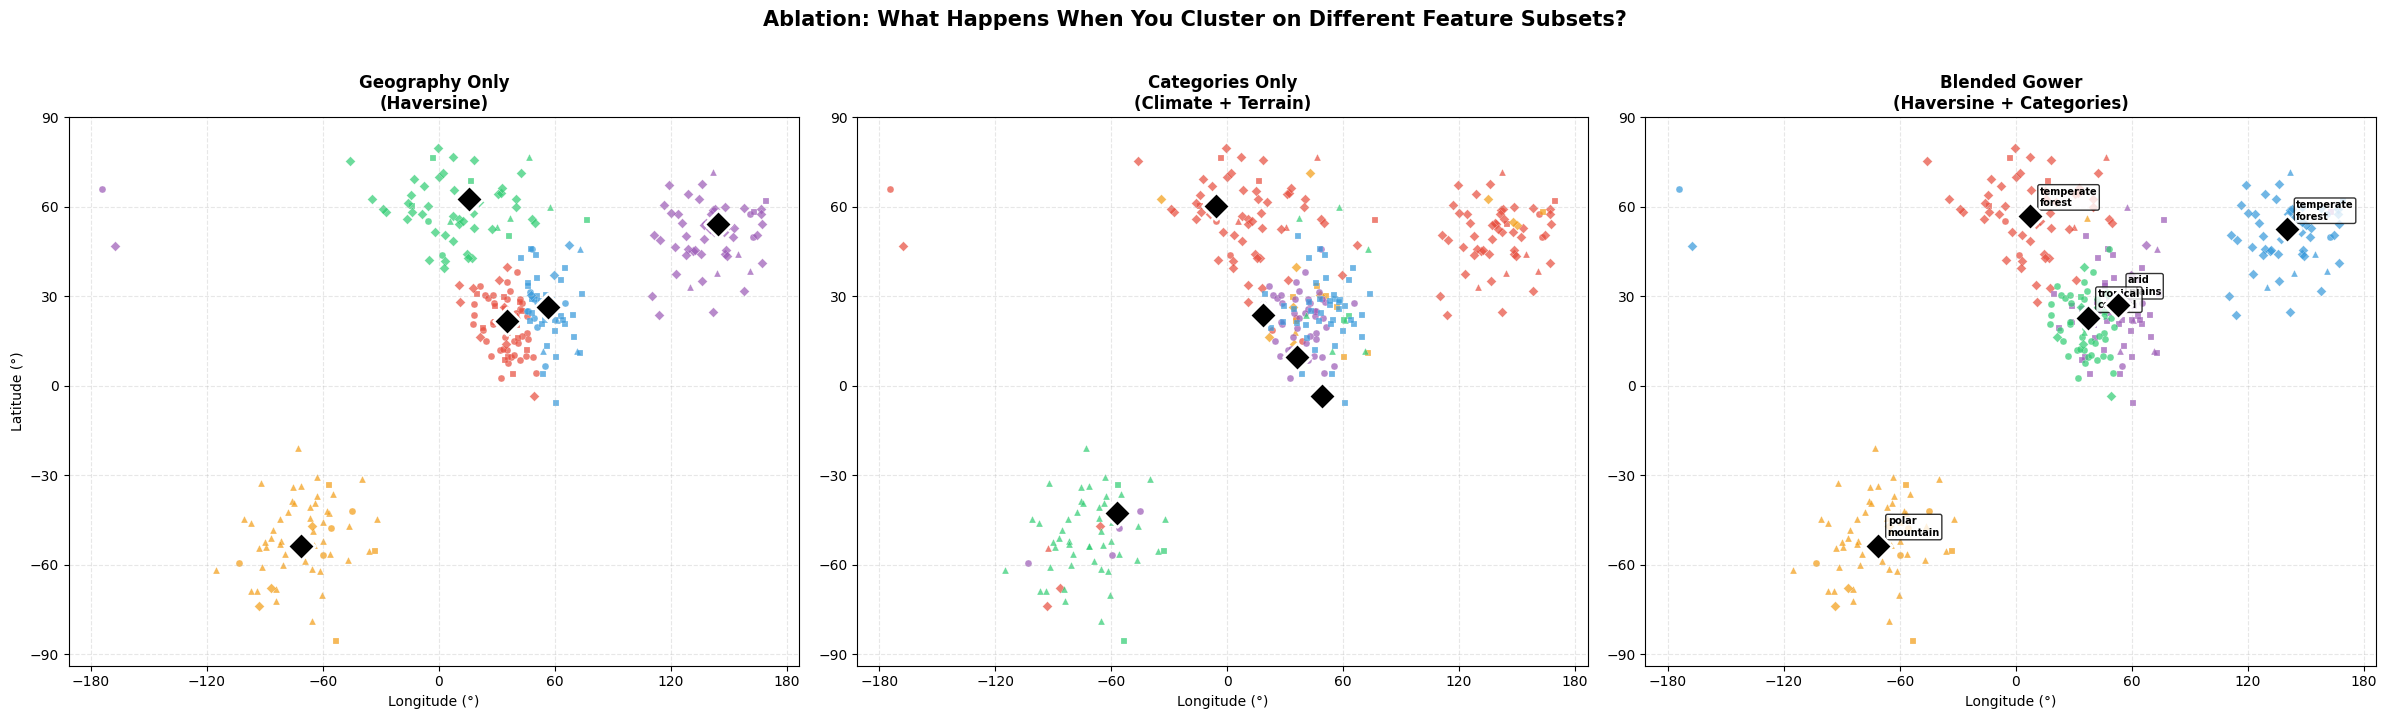

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

ablation_configs = [
    ('Geography Only\n(Haversine)', geo_labels, geo_medoids),
    ('Categories Only\n(Climate + Terrain)', cat_labels, cat_medoids),
    ('Blended Gower\n(Haversine + Categories)', gower_labels, gower_medoids),
]

for idx, (title, lbls, meds) in enumerate(ablation_configs):
    ax = axes[idx]
    plot_clustered_map(ax, lbls, meds, data, title, show_medoid_info=(idx == 2))
    ax.set_xlabel('Longitude (°)')
    if idx == 0:
        ax.set_ylabel('Latitude (°)')

plt.suptitle('Ablation: What Happens When You Cluster on Different Feature Subsets?',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 5c. Gower Distance Matrix Heatmap

Sorted by cluster assignment to reveal the block-diagonal structure.

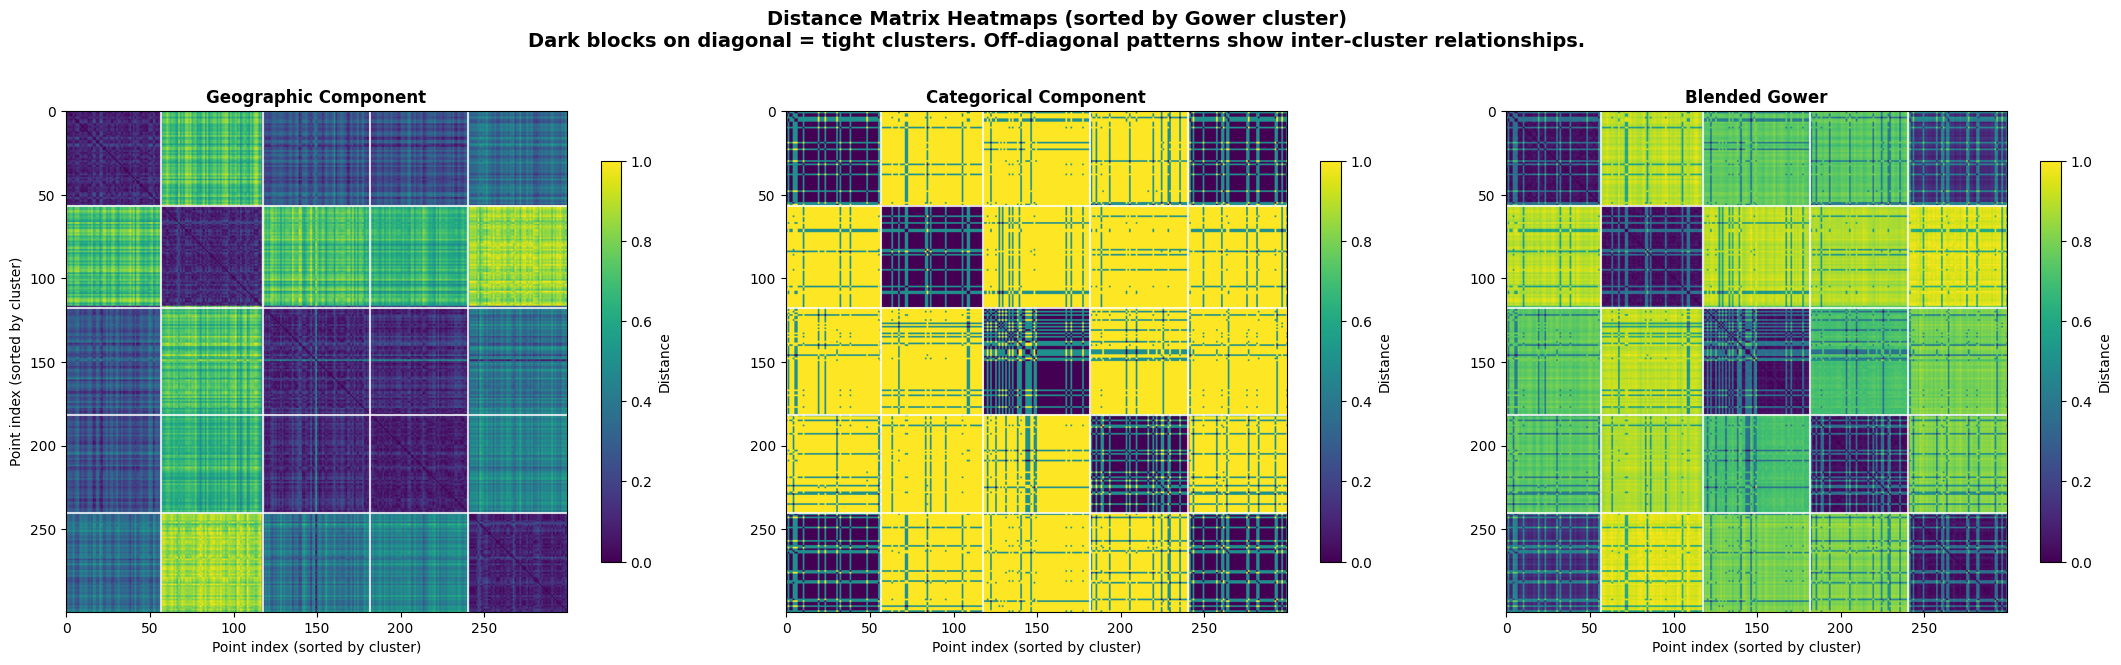

💡 Geographic matrix: clusters 1&2 are close (light off-diagonal block between them)
   Categorical matrix: clusters 4&5 are similar (light off-diagonal block between them)
   Blended Gower: best of both — clean block-diagonal structure


In [8]:
# Sort points by Gower cluster assignment
sort_idx = np.argsort(gower_labels)
D_sorted = D_gower[np.ix_(sort_idx, sort_idx)]

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

matrices = [
    ('Geographic Component', D_geo[np.ix_(sort_idx, sort_idx)]),
    ('Categorical Component', D_cat[np.ix_(sort_idx, sort_idx)]),
    ('Blended Gower', D_sorted),
]

for idx, (title, mat) in enumerate(matrices):
    ax = axes[idx]
    im = ax.imshow(mat, cmap='viridis', aspect='equal', vmin=0, vmax=1)
    
    # Draw cluster boundaries
    counts = [np.sum(gower_labels == i) for i in range(K)]
    boundaries = np.cumsum(counts)
    for b in boundaries[:-1]:
        ax.axhline(b - 0.5, color='white', linewidth=1.5, alpha=0.8)
        ax.axvline(b - 0.5, color='white', linewidth=1.5, alpha=0.8)
    
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Point index (sorted by cluster)')
    if idx == 0:
        ax.set_ylabel('Point index (sorted by cluster)')
    plt.colorbar(im, ax=ax, shrink=0.8, label='Distance')

plt.suptitle('Distance Matrix Heatmaps (sorted by Gower cluster)\n'
             'Dark blocks on diagonal = tight clusters. Off-diagonal patterns show inter-cluster relationships.',
             fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

print("💡 Geographic matrix: clusters 1&2 are close (light off-diagonal block between them)")
print("   Categorical matrix: clusters 4&5 are similar (light off-diagonal block between them)")
print("   Blended Gower: best of both — clean block-diagonal structure")

### 5d. Cluster Composition Analysis

For each cluster, what's the breakdown of climate and terrain? This shows whether the clusters are coherent across all feature types.

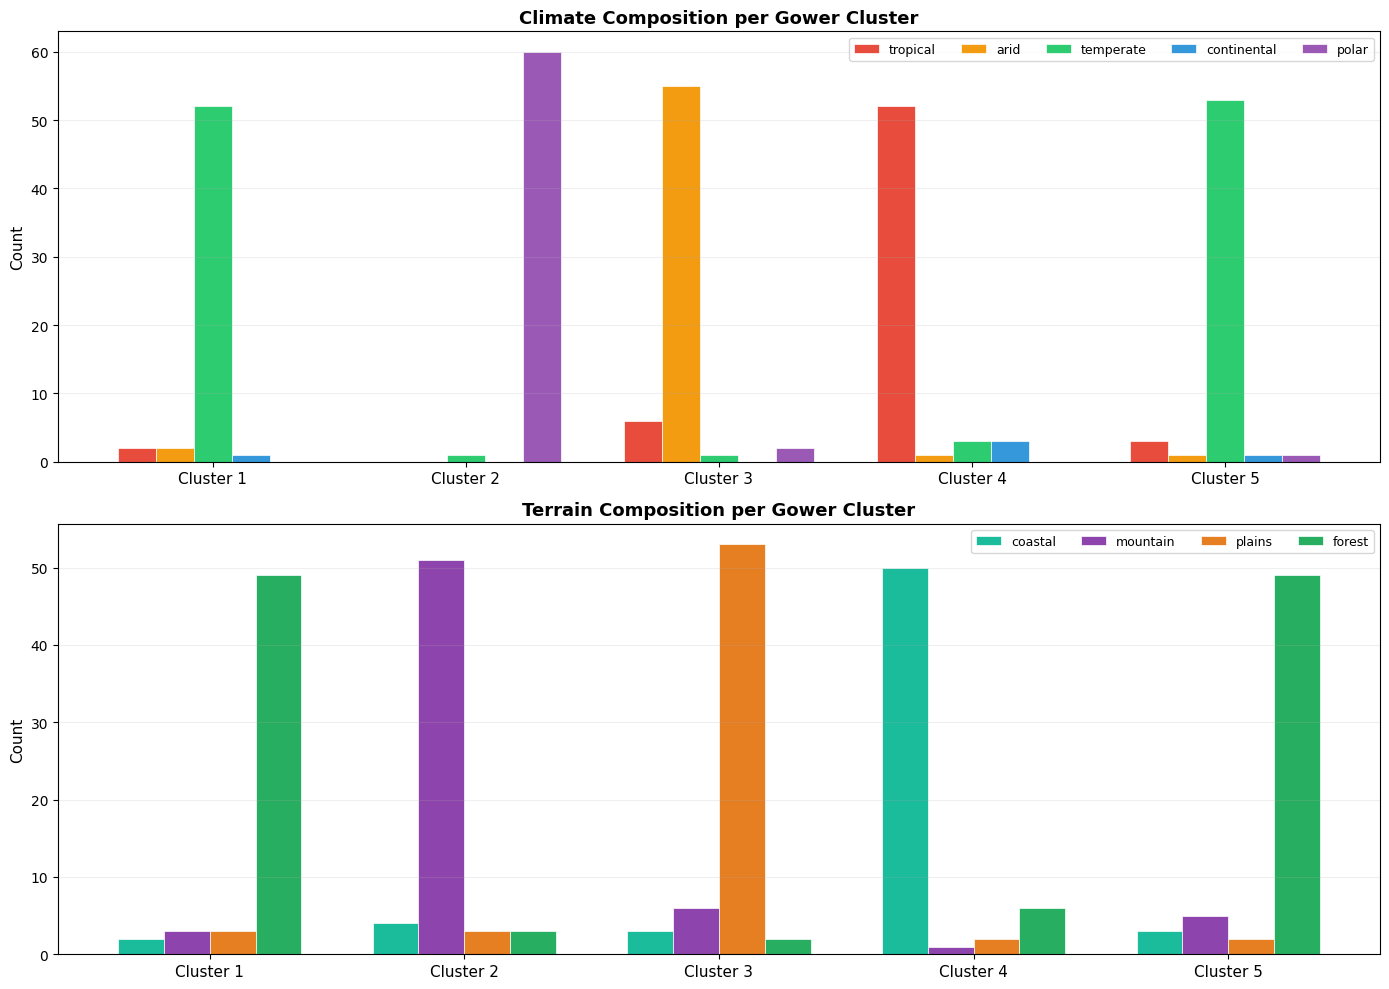

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Climate breakdown per cluster
ax = axes[0]
climate_colors = {'tropical': '#e74c3c', 'arid': '#f39c12', 'temperate': '#2ecc71',
                  'continental': '#3498db', 'polar': '#9b59b6'}
x = np.arange(K)
width = 0.15

for j, clim in enumerate(CLIMATES):
    counts = [np.sum((gower_labels == i) & (data['climate'] == clim)) for i in range(K)]
    ax.bar(x + j * width, counts, width, label=clim, color=climate_colors[clim],
           edgecolor='white', linewidth=0.5)

ax.set_xticks(x + width * 2)
ax.set_xticklabels([f'Cluster {i+1}' for i in range(K)], fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_title('Climate Composition per Gower Cluster', fontsize=13, fontweight='bold')
ax.legend(fontsize=9, ncol=5)
ax.grid(True, alpha=0.2, axis='y')

# Terrain breakdown per cluster
ax = axes[1]
terrain_colors = {'coastal': '#1abc9c', 'mountain': '#8e44ad', 'plains': '#e67e22', 'forest': '#27ae60'}
width = 0.18

for j, terr in enumerate(TERRAINS):
    counts = [np.sum((gower_labels == i) & (data['terrain'] == terr)) for i in range(K)]
    ax.bar(x + j * width, counts, width, label=terr, color=terrain_colors[terr],
           edgecolor='white', linewidth=0.5)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels([f'Cluster {i+1}' for i in range(K)], fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_title('Terrain Composition per Gower Cluster', fontsize=13, fontweight='bold')
ax.legend(fontsize=9, ncol=4)
ax.grid(True, alpha=0.2, axis='y')

plt.tight_layout()
plt.show()

---
## 6. Weight Sensitivity Analysis

The practical question: **how much should geography vs categories influence clustering?**

We sweep the geographic weight from 0 (categories only) to 1 (geography only) and track how cluster assignments change.

In [10]:
from itertools import combinations

def rand_index(labels_a, labels_b):
    """Rand Index between two clusterings."""
    n = len(labels_a)
    agree, total = 0, 0
    for i, j in combinations(range(n), 2):
        if (labels_a[i] == labels_a[j]) == (labels_b[i] == labels_b[j]):
            agree += 1
        total += 1
    return agree / total


# Sweep geographic weight
geo_weights = [0.0, 0.1, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0, 3.0, 5.0]
sweep_labels = []
sweep_costs = []

print("Sweeping geographic weight (categorical weight fixed at 1.0)...")
for w_g in geo_weights:
    D_sweep = gower_distance_matrix(data, w_geo=w_g, w_climate=1.0, w_terrain=1.0)
    lbls, meds, hist = kmedoids_pam(D_sweep, k=K, max_iter=30)
    sweep_labels.append(lbls)
    sweep_costs.append(hist[-1])
    print(f"  w_geo={w_g:4.1f}: cluster sizes = {[np.sum(lbls == i) for i in range(K)]}")

print("Done!")

Sweeping geographic weight (categorical weight fixed at 1.0)...
  Converged at swap iteration 2
  w_geo= 0.0: cluster sizes = [np.int64(121), np.int64(20), np.int64(54), np.int64(61), np.int64(44)]
  Converged at swap iteration 4
  w_geo= 0.1: cluster sizes = [np.int64(107), np.int64(61), np.int64(15), np.int64(55), np.int64(62)]
  Converged at swap iteration 4
  w_geo= 0.2: cluster sizes = [np.int64(107), np.int64(61), np.int64(15), np.int64(55), np.int64(62)]
  Converged at swap iteration 4
  w_geo= 0.5: cluster sizes = [np.int64(107), np.int64(61), np.int64(15), np.int64(62), np.int64(55)]
  Converged at swap iteration 5
  w_geo= 0.8: cluster sizes = [np.int64(57), np.int64(61), np.int64(64), np.int64(59), np.int64(59)]
  Converged at swap iteration 5
  w_geo= 1.0: cluster sizes = [np.int64(57), np.int64(61), np.int64(64), np.int64(59), np.int64(59)]
  Converged at swap iteration 5
  w_geo= 1.5: cluster sizes = [np.int64(57), np.int64(61), np.int64(64), np.int64(59), np.int64(59)]
 

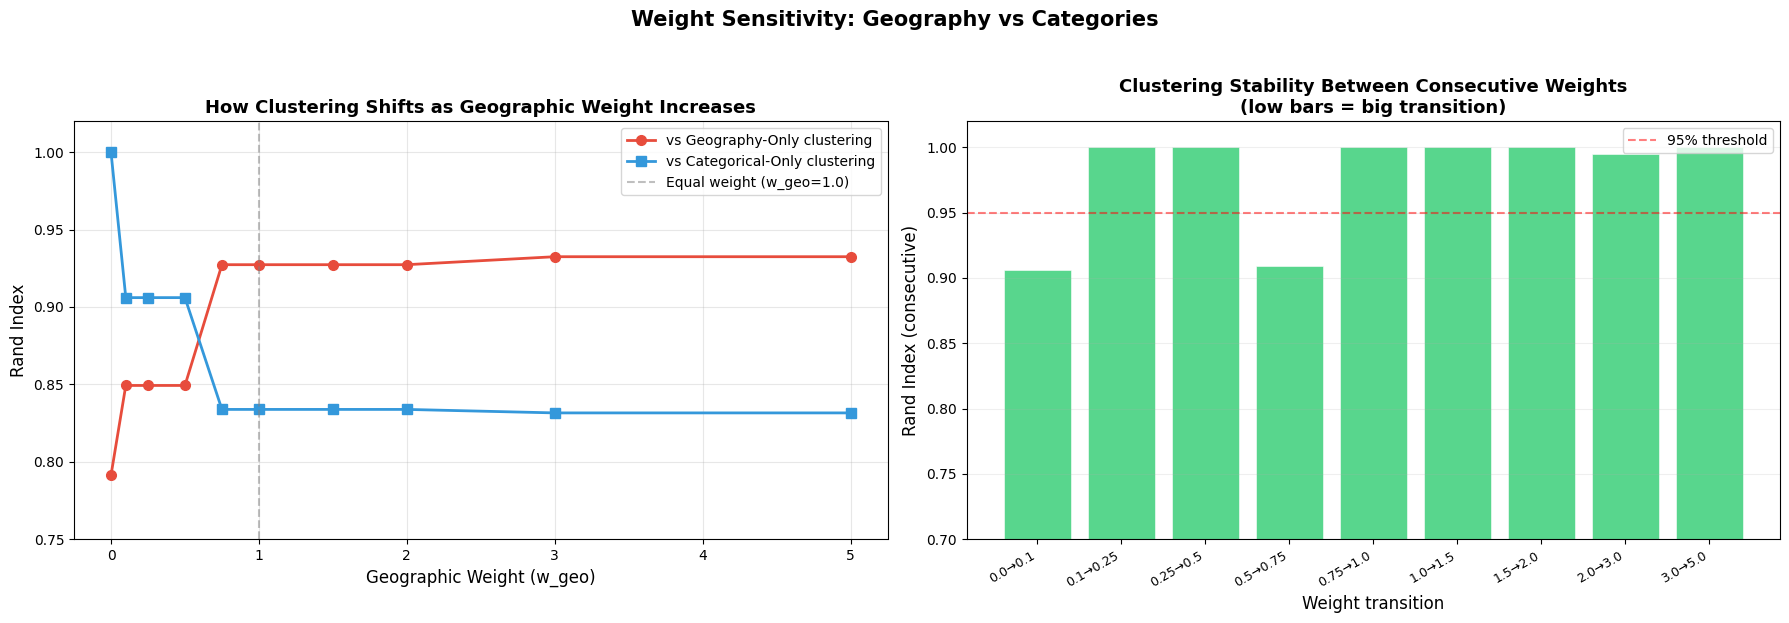

💡 The left plot shows a smooth crossover: low w_geo → categorical-like clustering,
   high w_geo → geography-like clustering.
   The right plot shows WHERE the biggest transition happens — that's the weight
   range where your choice of balance matters most.


In [11]:
# Compute RI of each sweep result vs geo-only and cat-only
ri_vs_geo = [rand_index(sl, geo_labels) for sl in sweep_labels]
ri_vs_cat = [rand_index(sl, cat_labels) for sl in sweep_labels]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# RI similarity to pure endpoints
ax = axes[0]
ax.plot(geo_weights, ri_vs_geo, 'o-', color='#e74c3c', linewidth=2, markersize=7,
        label='vs Geography-Only clustering')
ax.plot(geo_weights, ri_vs_cat, 's-', color='#3498db', linewidth=2, markersize=7,
        label='vs Categorical-Only clustering')
ax.axvline(x=1.0, color='gray', linestyle='--', alpha=0.5, label='Equal weight (w_geo=1.0)')
ax.set_xlabel('Geographic Weight (w_geo)', fontsize=12)
ax.set_ylabel('Rand Index', fontsize=12)
ax.set_title('How Clustering Shifts as Geographic Weight Increases',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim(0.75, 1.02)

# Stability: RI between consecutive weight values
ax = axes[1]
ri_consecutive = [rand_index(sweep_labels[i], sweep_labels[i+1])
                  for i in range(len(sweep_labels) - 1)]
mid_weights = [(geo_weights[i] + geo_weights[i+1]) / 2 for i in range(len(geo_weights) - 1)]

ax.bar(range(len(ri_consecutive)), ri_consecutive, color='#2ecc71', edgecolor='white',
       linewidth=0.5, alpha=0.8)
ax.set_xticks(range(len(ri_consecutive)))
ax.set_xticklabels([f'{geo_weights[i]}→{geo_weights[i+1]}' for i in range(len(geo_weights)-1)],
                    fontsize=9, rotation=30, ha='right')
ax.set_ylabel('Rand Index (consecutive)', fontsize=12)
ax.set_xlabel('Weight transition', fontsize=12)
ax.set_title('Clustering Stability Between Consecutive Weights\n(low bars = big transition)',
             fontsize=13, fontweight='bold')
ax.axhline(y=0.95, color='red', linestyle='--', alpha=0.5, label='95% threshold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.2, axis='y')
ax.set_ylim(0.7, 1.02)

plt.suptitle('Weight Sensitivity: Geography vs Categories',
             fontsize=15, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

print("💡 The left plot shows a smooth crossover: low w_geo → categorical-like clustering,")
print("   high w_geo → geography-like clustering.")
print("   The right plot shows WHERE the biggest transition happens — that's the weight")
print("   range where your choice of balance matters most.")

## Choosing K — PVE & Silhouette Analysis

How do we know K = 5 is the right number of clusters? We use two metrics:

**PVE (Proportion of Variance Explained)**

$$\text{PVE}(K) = 1 - \frac{\text{TWCSS}_K}{\text{TWCSS}_1}$$

where $\text{TWCSS}_K$ is the **total within-cluster sum of squared distances** for K clusters and $\text{TWCSS}_1$ is the single-cluster baseline (all points assigned to one cluster). PVE ranges from 0 to 1; an "elbow" in the curve marks a natural K choice.

**Silhouette Score**

For each point $i$:

$$s(i) = \frac{b(i) - a(i)}{\max(a(i),\, b(i))} \in [-1, +1]$$

where $a(i)$ = mean distance to other points in the **same** cluster (cohesion), and $b(i)$ = mean distance to points in the **nearest other** cluster (separation). Computed from the precomputed pairwise distance matrix so it automatically respects this notebook's metric.

In [ ]:
def silhouette_from_matrix(D, labels):
    """
    Mean silhouette score from a precomputed N×N distance matrix.
    s(i) = (b(i) - a(i)) / max(a(i), b(i))
    """
    n = len(labels)
    unique_clusters = np.unique(labels)
    if len(unique_clusters) <= 1:
        return 0.0
    scores = np.zeros(n)
    for i in range(n):
        ci = labels[i]
        same_mask = (labels == ci).copy()
        same_mask[i] = False
        a_i = float(np.mean(D[i, same_mask])) if np.any(same_mask) else 0.0
        b_i = np.inf
        for cj in unique_clusters:
            if cj == ci:
                continue
            other_mask = (labels == cj)
            if np.any(other_mask):
                b_i = min(b_i, float(np.mean(D[i, other_mask])))
        denom = max(a_i, b_i)
        scores[i] = (b_i - a_i) / denom if denom > 1e-15 else 0.0
    return float(np.mean(scores))

In [ ]:
# D_gower is the precomputed N×N Gower distance matrix (already computed above).
# For K-Medoids, TWCSS = sum of squared Gower distances to each point's medoid.

# TWCSS baseline: single global medoid
global_med_idx = int(np.argmin(D_gower.sum(axis=1)))
TWCSS_1 = float(np.sum(D_gower[:, global_med_idx] ** 2))

K_range = range(2, 11)
pve_vals = []
sil_vals = []

print(f"{'K':>4} {'TWCSS':>10} {'PVE':>8} {'Silhouette':>12}")
print("-" * 38)
for k in K_range:
    lbls_k, medoids_k, _ = kmedoids_pam(D_gower, k=k, max_iter=100, seed=123)
    twcss_k = float(np.sum(D_gower[np.arange(len(data['lats'])), np.array(medoids_k)[lbls_k]] ** 2))
    pve = 1 - twcss_k / TWCSS_1
    sil = silhouette_from_matrix(D_gower, lbls_k)
    pve_vals.append(pve)
    sil_vals.append(sil)
    print(f"{k:>4} {twcss_k:>10.4f} {pve:>8.4f} {sil:>12.4f}")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
K_chosen = 5
K_vals = list(K_range)

ax = axes[0]
ax.plot(K_vals, pve_vals, 'o-', color='#2c3e50', linewidth=2, markersize=7,
        markerfacecolor='#3498db', markeredgecolor='white', markeredgewidth=1.5)
ax.axvline(K_chosen, color='#e74c3c', linestyle='--', linewidth=1.8,
           label=f'Chosen K = {K_chosen}')
ax.fill_between(K_vals, pve_vals, alpha=0.08, color='#3498db')
ax.set_xlabel('Number of Clusters K', fontsize=12)
ax.set_ylabel('PVE', fontsize=12)
ax.set_title('PVE Elbow Curve', fontsize=13, fontweight='bold')
ax.legend(fontsize=11); ax.set_xticks(K_vals); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(K_vals, sil_vals, 's-', color='#2c3e50', linewidth=2, markersize=7,
        markerfacecolor='#9b59b6', markeredgecolor='white', markeredgewidth=1.5)
best_k_sil = K_vals[int(np.argmax(sil_vals))]
ax.axvline(best_k_sil, color='#9b59b6', linestyle='--', linewidth=1.8,
           label=f'Best silhouette K = {best_k_sil}')
ax.axvline(K_chosen, color='#e74c3c', linestyle=':', linewidth=1.8,
           label=f'Chosen K = {K_chosen}')
ax.fill_between(K_vals, sil_vals, alpha=0.08, color='#9b59b6')
ax.set_xlabel('Number of Clusters K', fontsize=12)
ax.set_ylabel('Mean Silhouette Score', fontsize=12)
ax.set_title('Silhouette Score vs K', fontsize=13, fontweight='bold')
ax.legend(fontsize=11); ax.set_xticks(K_vals); ax.grid(True, alpha=0.3)

plt.suptitle('Choosing K: PVE & Silhouette Validation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nK=2..10 summary:")
print(f"{'K':>4} {'PVE':>8} {'Silhouette':>12}")
print("-" * 27)
for k, pve, sil in zip(K_vals, pve_vals, sil_vals):
    marker = " ◄ chosen" if k == K_chosen else ""
    print(f"{k:>4} {pve:>8.4f} {sil:>12.4f}{marker}")

---
## 7. Summary

| Component | Distance Used | Range | What It Captures |
|-----------|-------------|-------|------------------|
| **Geographic** | Haversine / π | [0, 1] | Spatial proximity on the globe |
| **Climate** | Simple matching | {0, 1} | Whether climate types agree |
| **Terrain** | Simple matching | {0, 1} | Whether terrain types agree |
| **Gower (blended)** | Weighted average | [0, 1] | Overall similarity across all features |

### Key Takeaways

1. **Gower distance is the Swiss Army knife** for mixed data. It normalizes everything to [0, 1] and lets you blend any combination of numerical, categorical, and even custom distances (like Haversine).

2. **K-Medoids + Gower is a powerful combination.** You only need a distance matrix — no need to define what a "mean" of categories looks like. The medoid is always a real data point with interpretable features.

3. **The weight parameter is a modeling choice, not a technical one.** There's no universally "correct" balance — it depends on whether your application cares more about geographic proximity or attribute similarity.

4. **The ablation (geography-only vs categories-only vs blended) is essential.** It shows you what each feature type contributes and helps justify your weight choices to stakeholders.

### Complete Project Map

| Surface / Space | Distance Metrics | Algorithm | Notebook |
|----------------|-----------------|-----------|----------|
| Sphere | Haversine, Vincenty, Cosine | K-Means | Spherical K-Means |
| Hyperbolic plane | Poincaré disk metric | K-Means | Hyperbolic K-Means |
| Torus | Flat torus (wraparound) | K-Means | Torus K-Means |
| Feature space (ℝⁿ) | L1, L2, L∞, Mahalanobis | K-Means | Mahalanobis & Minkowski |
| Sphere | Haversine | K-Medoids (PAM) | K-Medoids on Sphere |
| Mixed (sphere + categorical) | Gower (Haversine + matching) | K-Medoids (PAM) | **This notebook** |